## Demo Usage of this Project's Custom DataLoaders

The DataLoader loads batches of images of movie posters, as well as their corresponding genre label. 

In [1]:
import torch
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from torchvision import transforms
from data_loader.data_loaders import PosterDataset, label_encoding, get_splits, get_dataloader

In [8]:
df = pd.read_csv("../assets/metadata.csv")
label_to_idx, idx_to_label = label_encoding(df)
train_df, val_df, test_df = get_splits(df)

Train: 8 | Val: 1 | Test: 1


In [9]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

In [11]:
loader = get_dataloader(train_df, label_to_idx, transform, batch_size=5, shuffle=True, num_workers=0)
images, labels = next(iter(loader))
print(images.shape)

torch.Size([5, 3, 224, 224])


### Plot the first batch of posters

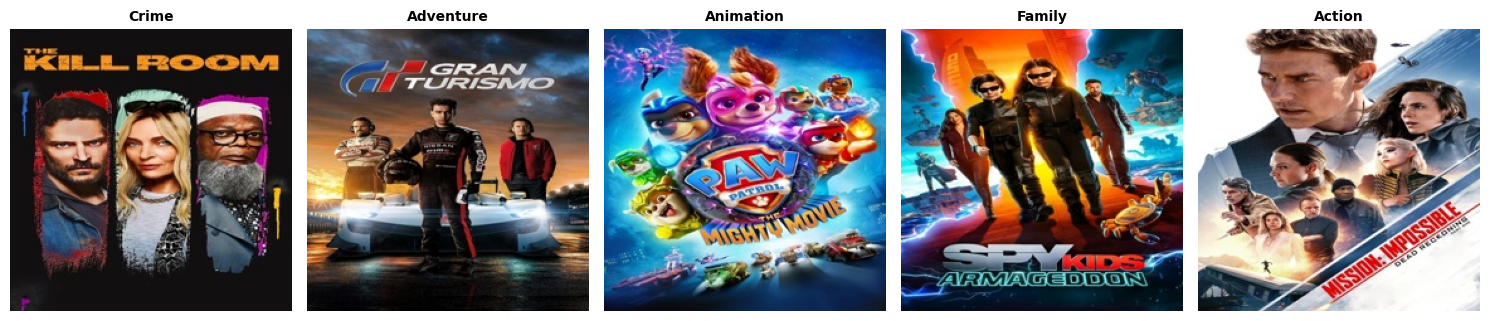

In [12]:
# Undo normalization on images
mean = [0.5, 0.5, 0.5]
std = [0.5, 0.5, 0.5]

plot_images = images * torch.tensor(std).view(1,3,1,1) + torch.tensor(mean).view(1,3,1,1)
plot_images = (plot_images * 255.0).numpy().transpose(0, 2, 3, 1).astype(np.uint8)

fig, axes = plt.subplots(1, len(plot_images), figsize=(3 * len(plot_images), 4))

for i, (img, label) in enumerate(zip(plot_images, labels)):
    axes[i].imshow(img)
    axes[i].set_title(idx_to_label[label.item()], fontsize=10, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('../assets/sample_batch.png', bbox_inches='tight', dpi=150)
plt.show()